In [1]:
import mocet
import os
import pickle
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from numpy.polynomial.legendre import Legendre
from sklearn.linear_model import LinearRegression

def make_poly_regressors(n_samples, order=2):
    X = np.ones((n_samples, 0))
    for d in range(order):
        poly = Legendre.basis(d + 1)
        poly_trend = poly(np.linspace(-1, 1, n_samples))
        X = np.hstack((X, poly_trend[:, None]))
    return X

def polynomial_detrending(pupil_data, polynomial_order):
    X = make_poly_regressors(len(pupil_data), order=polynomial_order)
    dedrift_regressor = np.zeros((len(pupil_data), 2))
    for i in range(2):
        reg = LinearRegression().fit(X, pupil_data[:, i])
        dedrift_regressor[:, i] = reg.predict(X)
    pupil_data = pupil_data[:, :2] - dedrift_regressor
    return pupil_data

subject_pool = {
                'sub-003':{'ses-07R':([1,2,3,4,5], False),
                           'ses-13R':([1,2,4,5,6], False)},
                'sub-004':{'ses-07R':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-005':{'ses-07':([1,2,3,4,5,6], True)},
                'sub-006':{'ses-07R':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-008':{'ses-07R':([2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-009':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,5,6], False)},
                'sub-010':{'ses-07':([1,2,3,4,5], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-011':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-012':{'ses-07':([1,2,4,5,6], False)},
                'sub-013':{'ses-07':([1,2,3,4], False)},
                'sub-014':{'ses-07':([2,3,4,5,6], False)},
                'sub-015':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-016':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-017':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5], False)},
                'sub-018':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-020':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-021':{'ses-07':([1,2,4,5,6], False),
                           'ses-13':([1,2,4,5,6], False)},
                'sub-JJY':{'ses-07':([1,2,3,4,5,6], False)},
                'sub-KMY':{'ses-07':([1,2,3,4,5,6], False)},
                'sub-PJW':{'ses-07':([1,2,3,4,6], True)},
                'sub-PBJ':{'ses-07':([1,2,3,4,5], False)}
                }

history_onset = {'sub-005': [28.66, 29.32, 28.12, 33.7, 36.1, 27.46],
                 'sub-PJW': [35, 30.8, 28.66, 26.58, None, 27.42]}
task_duration = 816

calibration_onsets = [1, 494]
calibration_points = [24, 12]
interval = 1.6 
calibration_offset_start = 0.55
calibration_offset_end = -0.55
px_per_deg = 78.43
task = 'task-mcHERDING'
method = 'linear'
testable_data = pickle.load(open('../testable_data_list.pkl', 'rb'))

subjects = []
subjects_runs = {}
for key in list(testable_data.keys()):
    subjects.append(key[0])
    if not subjects_runs.keys().__contains__(key[0]):
        subjects_runs[key[0]] = 0
    subjects_runs[key[0]] += 1
subjects = list(set(subjects))
subjects.sort()

print(len(subjects), subjects)

20 ['sub-003', 'sub-004', 'sub-005', 'sub-006', 'sub-008', 'sub-009', 'sub-010', 'sub-011', 'sub-012', 'sub-013', 'sub-014', 'sub-015', 'sub-016', 'sub-018', 'sub-020', 'sub-021', 'sub-JJY', 'sub-KMY', 'sub-PBJ', 'sub-PJW']


In [8]:
print(np.mean(list(subjects_runs.values())), np.std(list(subjects_runs.values())))

5.55 2.8718460961548757


In [2]:
mocet_calibration_errors = {}
mocet_validation_errors = {}

for subject in subjects:
    sessions = subject_pool[subject].keys()
    for session in sessions:
        runs, history_loss = subject_pool[subject][session]
        root = f'../../_DATA/{subject}/{session}'
        for r in runs:
            run = f'run-{r}'
            np.random.seed(0)
            key = (subject, session, task, run)
            if key in testable_data.keys():
                if not mocet_calibration_errors.keys().__contains__(subject):
                    mocet_calibration_errors[subject] = []
                    mocet_validation_errors[subject] = []
                
                log_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_log.csv'
                data_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_dat.txt'
                confounds_fname = f'{root}/{subject}_{session}_{task}_{run}_desc-confounds_timeseries.tsv'
                
                if history_loss: 
                    start = history_onset[subject][r-1]
                else:
                    history_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_his.txt'
                    start, _, _ = mocet.utils.get_avotec_history(history_fname)
                
                # log, data, confound, start
                pupil_data, pupil_timestamps, pupil_confidence, pupil_diameter = mocet.utils.clean_avotec_data(log_fname,
                                                                                                        data_fname,
                                                                                                        start=start,
                                                                                                        duration=task_duration)
                pupil_data = mocet.apply_mocet(pupil_data, confounds_fname,
                                               large_motion_params=False ,
                                               polynomial_order=3)
                
                
                t_cal = testable_data[key][0]
                t_val = testable_data[key][2]
            
                offset = calibration_onsets[t_cal]
                calibration_pupils = []
                for i in np.arange(calibration_points[t_cal]):
                    start = (offset+i)*interval + calibration_offset_start
                    end = (offset+i+1)*interval + calibration_offset_end
                    log_effective = np.logical_and(pupil_timestamps >= start*1000, pupil_timestamps < end*1000)
                    calibration_pupils.append([np.nanmean(pupil_data[log_effective,0]),
                                              np.nanmean(pupil_data[log_effective,1])])
                calibration_pupils = np.array(calibration_pupils)
            
                repeat = True if calibration_points[t_cal]==24 else False
                calibrator = mocet.EyetrackingCalibration(repeat=repeat, method=method)
                calibrator.fit(calibration_pupils[:, 0], calibration_pupils[:, 1])
                gaze_coordinates = calibrator.transform(pupil_data)
            
                for t in [t_cal, t_val]:
                    MSE = []
                    offset = calibration_onsets[t]
                    for i in np.arange(calibration_points[t]):
                        ref_x = calibrator.calibration_coordinates[calibrator.calibration_order[i]][0]
                        ref_y = calibrator.calibration_coordinates[calibrator.calibration_order[i]][1]
                        start = (offset+i)*interval + calibration_offset_start
                        end = (offset+i+1)*interval + calibration_offset_end
                        gaze_idx_start = np.min(np.where(pupil_timestamps >= start*1000)[0])
                        gaze_idx_end = np.min(np.where(pupil_timestamps >= end*1000)[0])
                        eye_closed = np.isnan(pupil_confidence[gaze_idx_start:gaze_idx_end])
                        if np.any(~eye_closed):
                            data_x = np.nanmean(gaze_coordinates[gaze_idx_start:gaze_idx_end,0][~eye_closed])
                            data_y = np.nanmean(gaze_coordinates[gaze_idx_start:gaze_idx_end,1][~eye_closed])
                            MSE.append(np.sqrt((ref_x-data_x)**2 + (ref_y-data_y)**2))
                    if t == t_cal:
                        calibration_error = np.nanmean(MSE)/px_per_deg
                        mocet_calibration_errors[subject].append(calibration_error)
                    elif t == t_val:
                        validation_error = np.nanmean(MSE)/px_per_deg
                        mocet_validation_errors[subject].append(validation_error)
                print(key, calibration_error, validation_error)
subjects_mocet_calibration_errors = []
subjects_mocet_validation_errors = []
for key in mocet_calibration_errors.keys():
    subjects_mocet_calibration_errors.append(np.mean(mocet_calibration_errors[key], axis=0))
    subjects_mocet_validation_errors.append(np.mean(mocet_validation_errors[key], axis=0))
    
print(np.mean(subjects_mocet_calibration_errors), np.mean(subjects_mocet_validation_errors))

with open(f'data/mocet_calibration_error.pkl', 'wb') as f:
    pickle.dump(mocet_calibration_errors, f)
with open(f'data/mocet_validation_error.pkl', 'wb') as f:
    pickle.dump(mocet_validation_errors, f)

# p0: 1.7, p1: , p2: 1.48, p3: 1.35

('sub-003', 'ses-07R', 'task-mcHERDING', 'run-1') 0.28471840448587804 1.6688589401802871
('sub-003', 'ses-07R', 'task-mcHERDING', 'run-2') 0.21888753835809363 1.0661478527883717
('sub-003', 'ses-07R', 'task-mcHERDING', 'run-3') 0.34447453156220476 1.0298445001955183
('sub-003', 'ses-13R', 'task-mcHERDING', 'run-1') 0.5471095721589272 1.1191290037326045
('sub-003', 'ses-13R', 'task-mcHERDING', 'run-2') 0.3675964150045186 1.2939704275454222
('sub-003', 'ses-13R', 'task-mcHERDING', 'run-4') 0.4171112364344642 0.9051891930638573


KeyboardInterrupt: 

In [92]:
for p in range(13, 16):
    polynomial_calibration_errors = {}
    polynomial_validation_errors = {}
    
    for subject in subjects:
        sessions = subject_pool[subject].keys()
        for session in sessions:
            runs, history_loss = subject_pool[subject][session]
            root = f'../../_DATA/{subject}/{session}'
            for r in runs:
                run = f'run-{r}'
                np.random.seed(0)
                key = (subject, session, task, run)
                if key in testable_data.keys():
                    if not polynomial_calibration_errors.keys().__contains__(subject):
                        polynomial_calibration_errors[subject] = []
                        polynomial_validation_errors[subject] = []
                    
                    log_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_log.csv'
                    data_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_dat.txt'
                    confounds_fname = f'{root}/{subject}_{session}_{task}_{run}_desc-confounds_timeseries.tsv'
                    
                    if history_loss: 
                        start = history_onset[subject][r-1]
                    else:
                        history_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_his.txt'
                        start, _, _ = mocet.utils.get_avotec_history(history_fname)
                    
                    # log, data, confound, start
                    pupil_data, pupil_timestamps, pupil_confidence, pupil_diameter = mocet.utils.clean_avotec_data(log_fname,
                                                                                                            data_fname,
                                                                                                            start=start,
                                                                                                            duration=task_duration)
                    pupil_data = polynomial_detrending(pupil_data, polynomial_order=p)
                    
                    t_cal = testable_data[key][0]
                    t_val = testable_data[key][2]
                
                    offset = calibration_onsets[t_cal]
                    calibration_pupils = []
                    for i in np.arange(calibration_points[t_cal]):
                        start = (offset+i)*interval + calibration_offset_start
                        end = (offset+i+1)*interval + calibration_offset_end
                        log_effective = np.logical_and(pupil_timestamps >= start*1000, pupil_timestamps < end*1000)
                        calibration_pupils.append([np.nanmean(pupil_data[log_effective,0]),
                                                  np.nanmean(pupil_data[log_effective,1])])
                    calibration_pupils = np.array(calibration_pupils)
                    
                    repeat = True if calibration_points[t_cal]==24 else False
                    calibrator = mocet.EyetrackingCalibration(repeat=repeat, method=method)
                    calibrator.fit(calibration_pupils[:, 0], calibration_pupils[:, 1])
                    gaze_coordinates = calibrator.transform(pupil_data)
                
                    for t in [t_cal, t_val]:
                        MSE = []
                        offset = calibration_onsets[t]
                        for i in np.arange(calibration_points[t]):
                            ref_x = calibrator.calibration_coordinates[calibrator.calibration_order[i]][0]
                            ref_y = calibrator.calibration_coordinates[calibrator.calibration_order[i]][1]
                            start = (offset+i)*interval + calibration_offset_start
                            end = (offset+i+1)*interval + calibration_offset_end
                            gaze_idx_start = np.min(np.where(pupil_timestamps >= start*1000)[0])
                            gaze_idx_end = np.min(np.where(pupil_timestamps >= end*1000)[0])
                            eye_closed = np.isnan(pupil_confidence[gaze_idx_start:gaze_idx_end])
                            if np.any(~eye_closed):
                                data_x = np.nanmean(gaze_coordinates[gaze_idx_start:gaze_idx_end,0][~eye_closed])
                                data_y = np.nanmean(gaze_coordinates[gaze_idx_start:gaze_idx_end,1][~eye_closed])
                                MSE.append(np.sqrt((ref_x-data_x)**2 + (ref_y-data_y)**2))
                        if t == t_cal:
                            calibration_error = np.nanmean(MSE)/px_per_deg
                            polynomial_calibration_errors[subject].append(calibration_error)
                        elif t == t_val:
                            validation_error = np.nanmean(MSE)/px_per_deg
                            polynomial_validation_errors[subject].append(validation_error)
    with open(f'data/polynomial_calibration_error_p{p:02d}.pkl', 'wb') as f:
        pickle.dump(polynomial_calibration_errors, f)
    with open(f'data/polynomial_validation_error_p{p:02d}.pkl', 'wb') as f:
        pickle.dump(polynomial_validation_errors, f)
    
    subjects_polynomial_calibration_errors = []
    subjects_polynomial_validation_errors = []
    for key in mocet_calibration_errors.keys():
        subjects_polynomial_calibration_errors.append(np.mean(polynomial_calibration_errors[key], axis=0))
        subjects_polynomial_validation_errors.append(np.mean(polynomial_validation_errors[key], axis=0))
        
    print(p, np.mean(subjects_polynomial_calibration_errors), np.mean(subjects_polynomial_validation_errors))

13 0.5094534910416649 1.6160515629429373
14 0.5142337374614 1.6322029234525472
15 0.49624320512713965 1.501696462809121


In [141]:
from scipy.stats import ttest_rel

with open(f'data/mocet_validation_error.pkl', 'rb') as f:
    mocet_validation_errors = pickle.load(f)
subjects_mocet_validation_errors = []
for key in mocet_calibration_errors.keys():
    subjects_mocet_validation_errors.append(np.mean(mocet_validation_errors[key], axis=0))
    
    
for p in range(1, 13):
    with open(f'data/polynomial_validation_error_p{p:02d}.pkl', 'rb') as f:
        polynomial_validation_errors = pickle.load(f)
    
    subjects_polynomial_validation_errors = []
    for key in mocet_calibration_errors.keys():
        subjects_polynomial_validation_errors.append(np.mean(polynomial_validation_errors[key], axis=0))
        
    print(p, np.mean(subjects_polynomial_validation_errors), ttest_rel(subjects_mocet_validation_errors, subjects_polynomial_validation_errors))


1 5.864194782261348 TtestResult(statistic=-4.866231535185513, pvalue=0.00010725609474903115, df=19)
2 5.846887496105901 TtestResult(statistic=-5.0681363296299375, pvalue=6.829391682618903e-05, df=19)
3 3.0034449699985064 TtestResult(statistic=-4.959261800425398, pvalue=8.707691894891236e-05, df=19)
4 2.8940939638727357 TtestResult(statistic=-4.933980045867017, pvalue=9.214483887511849e-05, df=19)
5 1.801093238316638 TtestResult(statistic=-3.223459191043179, pvalue=0.004472535311061038, df=19)
6 1.846185139752396 TtestResult(statistic=-3.273220315411659, pvalue=0.00399934481701678, df=19)
7 1.7053376851347302 TtestResult(statistic=-2.0272372084433, pvalue=0.056901954896503376, df=19)
8 1.7053904262342616 TtestResult(statistic=-2.4154030526936547, pvalue=0.025959023032135726, df=19)
9 1.6881506693925814 TtestResult(statistic=-2.9825495484934774, pvalue=0.007651545431585943, df=19)
10 1.5893433716886711 TtestResult(statistic=-2.4070391952647734, pvalue=0.026415280096535973, df=19)
11 1.72

In [120]:
### Uncorrected Calibration and Validation Errors
uncorrected_calibration_errors = {}
uncorrected_validation_errors = {}
for subject in subjects:
    sessions = subject_pool[subject].keys()
    for session in sessions:
        runs, history_loss = subject_pool[subject][session]
        root = f'../../_DATA/{subject}/{session}'
        for r in runs:
            run = f'run-{r}'
            np.random.seed(0)
            key = (subject, session, task, run)
            if key in testable_data.keys():
                if not uncorrected_calibration_errors.keys().__contains__(subject):
                    uncorrected_calibration_errors[subject] = []
                    uncorrected_validation_errors[subject] = []
                
                log_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_log.csv'
                data_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_dat.txt'
                confounds_fname = f'{root}/{subject}_{session}_{task}_{run}_desc-confounds_timeseries.tsv'
                
                if history_loss: 
                    start = history_onset[subject][r-1]
                else:
                    history_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_his.txt'
                    start, _, _ = mocet.utils.get_avotec_history(history_fname)
                
                pupil_data, pupil_timestamps, pupil_confidence, pupil_diameter = mocet.utils.clean_avotec_data(log_fname,
                                                                                                        data_fname,
                                                                                                        start=start,
                                                                                                        duration=task_duration)
                t_cal = testable_data[key][0]
                t_val = testable_data[key][2]
            
                offset = calibration_onsets[t_cal]
                calibration_pupils = []
                for i in np.arange(calibration_points[t_cal]):
                    start = (offset+i)*interval + calibration_offset_start
                    end = (offset+i+1)*interval + calibration_offset_end
                    log_effective = np.logical_and(pupil_timestamps >= start*1000, pupil_timestamps < end*1000)
                    calibration_pupils.append([np.nanmean(pupil_data[log_effective,0]),
                                               np.nanmean(pupil_data[log_effective,1])])
                calibration_pupils = np.array(calibration_pupils)
                
                repeat = True if calibration_points[t_cal] == 24 else False
                calibrator = mocet.EyetrackingCalibration(repeat=repeat, method='linear')
                calibrator.fit(calibration_pupils[:, 0], calibration_pupils[:, 1])
                gaze_coordinates = calibrator.transform(pupil_data)
            
                for t in [t_cal, t_val]:
                    MSE = []
                    offset = calibration_onsets[t]
                    for i in np.arange(calibration_points[t]):
                        ref_x = calibrator.calibration_coordinates[calibrator.calibration_order[i]][0]
                        ref_y = calibrator.calibration_coordinates[calibrator.calibration_order[i]][1]
                        start = (offset+i)*interval + calibration_offset_start
                        end = (offset+i+1)*interval + calibration_offset_end
                        gaze_idx_start = np.min(np.where(pupil_timestamps >= start*1000)[0])
                        gaze_idx_end = np.min(np.where(pupil_timestamps >= end*1000)[0])
                        eye_closed = np.isnan(pupil_confidence[gaze_idx_start:gaze_idx_end])
                        if np.any(~eye_closed):
                            data_x = np.nanmean(gaze_coordinates[gaze_idx_start:gaze_idx_end,0][~eye_closed])
                            data_y = np.nanmean(gaze_coordinates[gaze_idx_start:gaze_idx_end,1][~eye_closed])
                            MSE.append(np.sqrt((ref_x-data_x)**2 + (ref_y-data_y)**2))
                    if t == t_cal:
                        calibration_error = np.nanmean(MSE)/px_per_deg
                        uncorrected_calibration_errors[subject].append(calibration_error)
                    elif t == t_val:
                        validation_error = np.nanmean(MSE)/px_per_deg
                        uncorrected_validation_errors[subject].append(validation_error)
        
subjects_uncorrected_calibration_errors = []
subjects_uncorrected_validation_errors = []
for key in mocet_calibration_errors.keys():
    subjects_uncorrected_calibration_errors.append(np.mean(uncorrected_calibration_errors[key], axis=0))
    subjects_uncorrected_validation_errors.append(np.mean(uncorrected_validation_errors[key], axis=0))
    
print(np.mean(subjects_uncorrected_calibration_errors), np.mean(subjects_uncorrected_validation_errors))

with open(f'data/uncorrected_calibration_error.pkl', 'wb') as f:
    pickle.dump(uncorrected_calibration_errors, f)
with open(f'data/uncorrected_validation_error.pkl', 'wb') as f:
    pickle.dump(uncorrected_validation_errors, f)


0.43488741670709413 7.093176873730745


(4, 20)


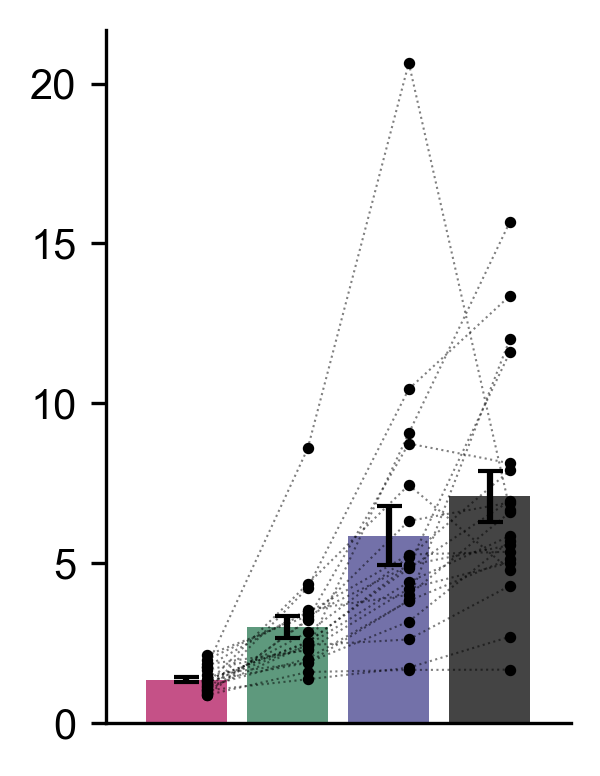

In [11]:
with open(f'data/mocet_validation_error.pkl', 'rb') as f:
    mocet_validation_errors = pickle.load(f)
subjects_mocet_validation_errors = []
for subject in subjects:
    subjects_mocet_validation_errors.append(np.mean(mocet_validation_errors[subject], axis=0))
    
with open(f'data/uncorrected_validation_error.pkl', 'rb') as f:
    uncorrected_validation_errors = pickle.load(f)
subjects_uncorrected_validation_errors = []
for subject in subjects:
    subjects_uncorrected_validation_errors.append(np.mean(uncorrected_validation_errors[subject], axis=0))
    
subjects_polynomial_validation_errors = []
for p in [1,3]:
    with open(f'data/polynomial_validation_error_p{p:02d}.pkl', 'rb') as f:
        polynomial_validation_errors = pickle.load(f)
    #subjects_polynomial_calibration_errors = []
    subject_polynomial_validation_errors = []
    for subject in subjects:
        #subjects_polynomial_calibration_errors.append(np.mean(polynomial_calibration_errors[key], axis=0))
        subject_polynomial_validation_errors.append(np.mean(polynomial_validation_errors[subject], axis=0))
    subjects_polynomial_validation_errors.append(subject_polynomial_validation_errors)
    
    
from scipy.stats import sem, ttest_rel, ttest_ind
plt.style.use('default')

# Define the tags for the errors
tags = ['mocet', 'polynomial', 'linear', 'uncorrected']

MSE_matrix = np.concatenate([
    np.array(subjects_mocet_validation_errors).reshape(1,-1), 
    np.flip(np.array(subjects_polynomial_validation_errors), axis=0),
    np.array(subjects_uncorrected_validation_errors).reshape(1,-1)
], axis=0)
print(MSE_matrix.shape)

#color_list = ['#c55187']+['#5e997d']*3+['#444444']
color_list = ['#c55187','#5e997d', '#7371a9', '#444444']

fig, ax = plt.subplots(1, 1, figsize=(2,3), dpi=300,  sharex=True)
ax.bar(np.arange(1+2+1),
       np.mean(MSE_matrix, axis=1),
       yerr=sem(MSE_matrix, axis=1),
       capsize=3, color=color_list)

# # Add scatter points to the box plot
for i in range(1+2+1):
    ax.scatter(np.ones(len(subjects_mocet_validation_errors)) * (i) + 0.2, MSE_matrix[i], s=3, c='k')

# Connect the scatter points
for s in range(len(subjects_mocet_validation_errors)):
    for i in range(1+2):
        ax.plot([i+0.2, i+1+0.2], [MSE_matrix[i, s], MSE_matrix[i+1, s]], c='k', linestyle=':', lw=0.5, alpha=0.5)
        
ax.spines[['right', 'top']].set_visible(False)
ax.set_xticks([])
ax.set_xlim(-0.8, 3.8)

for tick in ax.get_yticklabels():
    tick.set_fontname("Arial")
for tick in ax.get_xticklabels():
    tick.set_fontname("Arial")


In [161]:
print(ttest_rel(subjects_mocet_validation_errors, MSE_matrix[1]))
print(ttest_rel(subjects_mocet_validation_errors, MSE_matrix[2]))
print(ttest_rel(subjects_mocet_validation_errors, MSE_matrix[3]))

TtestResult(statistic=-4.959261800425398, pvalue=8.707691894891236e-05, df=19)
TtestResult(statistic=-4.866231535185513, pvalue=0.00010725609474903115, df=19)
TtestResult(statistic=-7.378239133839763, pvalue=5.454845562513752e-07, df=19)


(14, 20)


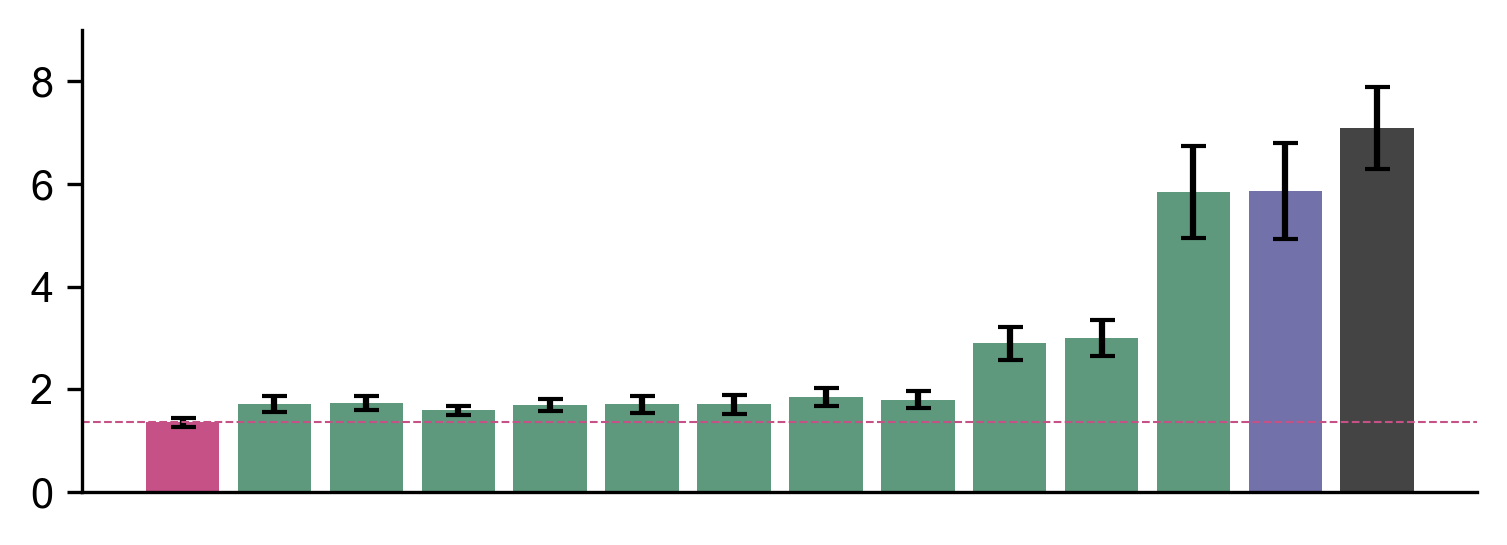

In [20]:
with open(f'data/mocet_validation_error.pkl', 'rb') as f:
    mocet_validation_errors = pickle.load(f)
subjects_mocet_validation_errors = []
for subject in subjects:
    subjects_mocet_validation_errors.append(np.mean(mocet_validation_errors[subject], axis=0))
    
with open(f'data/uncorrected_validation_error.pkl', 'rb') as f:
    uncorrected_validation_errors = pickle.load(f)
subjects_uncorrected_validation_errors = []
for subject in subjects:
    subjects_uncorrected_validation_errors.append(np.mean(uncorrected_validation_errors[subject], axis=0))
    
subjects_polynomial_validation_errors = []
for p in range(1,13):
    with open(f'data/polynomial_validation_error_p{p:02d}.pkl', 'rb') as f:
        polynomial_validation_errors = pickle.load(f)
    #subjects_polynomial_calibration_errors = []
    subject_polynomial_validation_errors = []
    for subject in subjects:
        #subjects_polynomial_calibration_errors.append(np.mean(polynomial_calibration_errors[key], axis=0))
        subject_polynomial_validation_errors.append(np.mean(polynomial_validation_errors[subject], axis=0))
    subjects_polynomial_validation_errors.append(subject_polynomial_validation_errors)
    
    
from scipy.stats import sem, ttest_rel, ttest_ind
plt.style.use('default')

# Define the tags for the errors
tags = ['mocet', 'polynomial', 'linear', 'uncorrected']

MSE_matrix = np.concatenate([
    np.array(subjects_mocet_validation_errors).reshape(1,-1), 
    np.flip(np.array(subjects_polynomial_validation_errors), axis=0),
    np.array(subjects_uncorrected_validation_errors).reshape(1,-1)
], axis=0)
print(MSE_matrix.shape)

color_list = ['#c55187']+['#5e997d']*11+['#7371a9', '#444444']
#color_list = ['#c55187','#5e997d', '#7371a9', '#444444']

fig, ax = plt.subplots(1, 1, figsize=(6,2), dpi=300,  sharex=True)
ax.bar(np.arange(MSE_matrix.shape[0]),
       np.mean(MSE_matrix, axis=1),
       yerr=sem(MSE_matrix, axis=1),
       capsize=3, color=color_list)

# # # Add scatter points to the box plot
# for i in range(MSE_matrix.shape[0]):
#     ax.scatter(np.ones(len(subjects_mocet_validation_errors)) * (i) + 0.2, MSE_matrix[i], s=3, c='k')
# 
# # Connect the scatter points
# for s in range(len(subjects_mocet_validation_errors)):
#     for i in range(MSE_matrix.shape[0]-1):
#         ax.plot([i+0.2, i+1+0.2], [MSE_matrix[i, s], MSE_matrix[i+1, s]], c='k', linestyle=':', lw=0.5, alpha=0.5)
#         
ax.spines[['right', 'top']].set_visible(False)
ax.set_xticks([])
ax.set_ylim(0, 9)
ax.axhline(np.mean(MSE_matrix, axis=1)[0], c='#c55187', linestyle='--', lw=0.5)

for tick in ax.get_yticklabels():
    tick.set_fontname("Arial")
for tick in ax.get_xticklabels():
    tick.set_fontname("Arial")
